In [ ]:
# --- 1. Mount Drive ---
from google.colab import drive
drive.mount('/content/drive')

import os
DRIVE_ROOT = '/content/drive/MyDrive/mrart_project'
DATA_DIR = f'{DRIVE_ROOT}/ds004173'
LOCAL_DATA_DIR = '/content/ds004173'
OUTPUT_DIR = f'{DRIVE_ROOT}/outputs'
os.makedirs(DRIVE_ROOT, exist_ok=True)
os.makedirs(OUTPUT_DIR, exist_ok=True)

# --- 2. Install packages ---
!pip install -q nibabel awscli

# --- 3. Copy dataset to local disk ---
!mkdir -p "{LOCAL_DATA_DIR}"
!rsync -a "{DATA_DIR}/" "{LOCAL_DATA_DIR}/"

# --- 4. Load data ---
import pandas as pd
import numpy as np
import nibabel as nib
from pathlib import Path

data_path = Path(LOCAL_DATA_DIR)
participants = pd.read_csv(data_path / 'participants.tsv', sep='\t')
scores = pd.read_csv(data_path / 'derivatives' / 'scores.tsv', sep='\t')
mriqc = pd.read_csv(data_path / 'derivatives' / 'mriqc-0.16.1' / 'group_T1w.tsv', sep='\t')
merged = mriqc.merge(scores, on='bids_name', how='inner')

# --- 5. Subject-level split ---
from sklearn.model_selection import train_test_split

subjects = participants['participant_id'].unique()
train_subj, temp_subj = train_test_split(subjects, test_size=0.3, random_state=42)
val_subj, test_subj = train_test_split(temp_subj, test_size=0.5, random_state=42)

def assign_split(bids_name):
    subj = bids_name.split('_')[0]
    if subj in train_subj: return 'train'
    elif subj in val_subj: return 'val'
    else: return 'test'

merged['split'] = merged['bids_name'].apply(assign_split)
train_df = merged[merged['split'] == 'train']
val_df = merged[merged['split'] == 'val']
test_df = merged[merged['split'] == 'test']

# --- 6. Dataset class ---
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from PIL import Image
import torch.nn as nn
import torch.optim as optim
from sklearn.utils.class_weight import compute_class_weight

class MRIQualityDataset(Dataset):
    def __init__(self, df, data_path, transform=None):
        self.df = df.reset_index(drop=True)
        self.data_path = data_path
        self.transform = transform
    def __len__(self):
        return len(self.df)
    def _get_2p5d_slice(self, bids_name):
        subject = bids_name.split('_')[0]
        fpath = self.data_path / subject / 'anat' / f'{bids_name}.nii.gz'
        vol = nib.load(fpath).get_fdata()
        z = vol.shape[2] // 2
        stack = np.stack([vol[:, :, z-1], vol[:, :, z], vol[:, :, z+1]], axis=-1)
        stack = stack - stack.min()
        stack = (stack / (stack.max() + 1e-8) * 255).astype(np.uint8)
        return stack
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = Image.fromarray(self._get_2p5d_slice(row['bids_name']))
        if self.transform:
            img = self.transform(img)
        label = int(row['score']) - 1
        return img, label

# --- 7. Dataloaders ---
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])
eval_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

train_dataset = MRIQualityDataset(train_df, data_path, transform=train_transform)
val_dataset = MRIQualityDataset(val_df, data_path, transform=eval_transform)
test_dataset = MRIQualityDataset(test_df, data_path, transform=eval_transform)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=16, shuffle=False, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False, num_workers=2)

# --- 8. Model setup ---
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Using device:', device)

model = models.resnet18(weights='IMAGENET1K_V1')
model.fc = nn.Linear(model.fc.in_features, 3)
model = model.to(device)

train_labels = (train_df['score'] - 1).values
class_weights = compute_class_weight('balanced', classes=np.array([0, 1, 2]), y=train_labels)
class_weights = torch.tensor(class_weights, dtype=torch.float32).to(device)

criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = optim.Adam(model.parameters(), lr=1e-4)

print("All set up! Ready to train.")

Mounted at /content/drive
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 20.2/20.2 MB 95.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 570.5/570.5 kB 44.0 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
sphinx 8.2.3 requires docutils<0.22,>=0.20, but you have docutils 0.19 which is incompatible.
Using device: cuda
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 139MB/s]


All set up! Ready to train.


In [ ]:
num_epochs = 10

for epoch in range(num_epochs):
    model.train()
    running_loss = 0
    correct = 0
    total = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    train_acc = correct / total
    print(f'Epoch {epoch+1}/{num_epochs} - Loss: {running_loss/len(train_loader):.4f} - Train Acc: {train_acc:.4f}')

Epoch 1/10 - Loss: 0.7622 - Train Acc: 0.6490
Epoch 2/10 - Loss: 0.4928 - Train Acc: 0.8046
Epoch 3/10 - Loss: 0.4494 - Train Acc: 0.8146
Epoch 4/10 - Loss: 0.2904 - Train Acc: 0.9139
Epoch 5/10 - Loss: 0.2288 - Train Acc: 0.9238
Epoch 6/10 - Loss: 0.1578 - Train Acc: 0.9603
Epoch 7/10 - Loss: 0.1520 - Train Acc: 0.9603
Epoch 8/10 - Loss: 0.1737 - Train Acc: 0.9470
Epoch 9/10 - Loss: 0.0769 - Train Acc: 0.9834
Epoch 10/10 - Loss: 0.0891 - Train Acc: 0.9735


In [ ]:
from sklearn.metrics import balanced_accuracy_score, f1_score, classification_report, confusion_matrix

def evaluate(loader):
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.numpy())

    return np.array(all_labels), np.array(all_preds)

val_labels, val_preds = evaluate(val_loader)
print("VALIDATION")
print(f'Balanced accuracy: {balanced_accuracy_score(val_labels, val_preds):.3f}')
print(f'Macro F1: {f1_score(val_labels, val_preds, average="macro"):.3f}')
print(classification_report(val_labels, val_preds))
print(confusion_matrix(val_labels, val_preds))

test_labels, test_preds = evaluate(test_loader)
print("\nTEST")
print(f'Balanced accuracy: {balanced_accuracy_score(test_labels, test_preds):.3f}')
print(f'Macro F1: {f1_score(test_labels, test_preds, average="macro"):.3f}')
print(classification_report(test_labels, test_preds))
print(confusion_matrix(test_labels, test_preds))

VALIDATION
Balanced accuracy: 0.735
Macro F1: 0.721
              precision    recall  f1-score   support

           0       0.73      0.95      0.83        20
           1       0.50      0.53      0.51        17
           2       0.95      0.72      0.82        29

    accuracy                           0.74        66
   macro avg       0.73      0.73      0.72        66
weighted avg       0.77      0.74      0.74        66

[[19  1  0]
 [ 7  9  1]
 [ 0  8 21]]

TEST
Balanced accuracy: 0.685
Macro F1: 0.679
              precision    recall  f1-score   support

           0       0.83      0.90      0.86        21
           1       0.38      0.40      0.39        15
           2       0.83      0.75      0.79        32

    accuracy                           0.72        68
   macro avg       0.68      0.68      0.68        68
weighted avg       0.73      0.72      0.72        68

[[19  2  0]
 [ 4  6  5]
 [ 0  8 24]]


In [ ]:
class MultiSliceMRIDataset(Dataset):
    def __init__(self, df, data_path, transform=None, offsets=[-10, -5, 0, 5, 10]):
        self.samples = []
        for _, row in df.iterrows():
            for offset in offsets:
                self.samples.append((row['bids_name'], int(row['score']) - 1, offset))
        self.data_path = data_path
        self.transform = transform

    def __len__(self):
        return len(self.samples)

    def _get_2p5d_slice(self, bids_name, offset):
        subject = bids_name.split('_')[0]
        fpath = self.data_path / subject / 'anat' / f'{bids_name}.nii.gz'
        vol = nib.load(fpath).get_fdata()
        z = vol.shape[2] // 2 + offset
        stack = np.stack([vol[:, :, z-1], vol[:, :, z], vol[:, :, z+1]], axis=-1)
        stack = stack - stack.min()
        stack = (stack / (stack.max() + 1e-8) * 255).astype(np.uint8)
        return stack

    def __getitem__(self, idx):
        bids_name, label, offset = self.samples[idx]
        img = Image.fromarray(self._get_2p5d_slice(bids_name, offset))
        if self.transform:
            img = self.transform(img)
        return img, label

train_dataset_multi = MultiSliceMRIDataset(train_df, data_path, transform=train_transform)
train_loader_multi = DataLoader(train_dataset_multi, batch_size=16, shuffle=True, num_workers=2)
print(f'Training samples: {len(train_dataset_multi)} (was {len(train_df)})')

Training samples: 1510 (was 302)


In [ ]:
# Fresh model so this is a clean before/after comparison
model = models.resnet18(weights='IMAGENET1K_V1')
model.fc = nn.Linear(model.fc.in_features, 3)
model = model.to(device)

optimizer = optim.Adam(model.parameters(), lr=1e-4)
# criterion and class_weights are unchanged from before

num_epochs = 10

for epoch in range(num_epochs):
    model.train()
    running_loss = 0
    correct = 0
    total = 0

    for images, labels in train_loader_multi:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    train_acc = correct / total
    print(f'Epoch {epoch+1}/{num_epochs} - Loss: {running_loss/len(train_loader_multi):.4f} - Train Acc: {train_acc:.4f}')

Epoch 1/10 - Loss: 0.7175 - Train Acc: 0.6921
Epoch 2/10 - Loss: 0.5129 - Train Acc: 0.7828
Epoch 3/10 - Loss: 0.4321 - Train Acc: 0.8278
Epoch 4/10 - Loss: 0.3696 - Train Acc: 0.8616
Epoch 5/10 - Loss: 0.2565 - Train Acc: 0.9073
Epoch 6/10 - Loss: 0.2303 - Train Acc: 0.9212
Epoch 7/10 - Loss: 0.2032 - Train Acc: 0.9344
Epoch 8/10 - Loss: 0.1761 - Train Acc: 0.9404
Epoch 9/10 - Loss: 0.1592 - Train Acc: 0.9444
Epoch 10/10 - Loss: 0.1117 - Train Acc: 0.9669


In [ ]:
import torch.nn.functional as F

def evaluate_multislice(df, offsets=[-10, -5, 0, 5, 10]):
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for _, row in df.iterrows():
            slices = []
            for offset in offsets:
                subject = row['bids_name'].split('_')[0]
                fpath = data_path / subject / 'anat' / f"{row['bids_name']}.nii.gz"
                vol = nib.load(fpath).get_fdata()
                z = vol.shape[2] // 2 + offset
                stack = np.stack([vol[:, :, z-1], vol[:, :, z], vol[:, :, z+1]], axis=-1)
                stack = stack - stack.min()
                stack = (stack / (stack.max() + 1e-8) * 255).astype(np.uint8)
                img = eval_transform(Image.fromarray(stack))
                slices.append(img)

            batch = torch.stack(slices).to(device)
            outputs = model(batch)
            probs = F.softmax(outputs, dim=1)
            avg_probs = probs.mean(dim=0)
            pred = torch.argmax(avg_probs).item()

            all_preds.append(pred)
            all_labels.append(int(row['score']) - 1)

    return np.array(all_labels), np.array(all_preds)

val_labels_ms, val_preds_ms = evaluate_multislice(val_df)
print("VALIDATION (multi-slice)")
print(f'Balanced accuracy: {balanced_accuracy_score(val_labels_ms, val_preds_ms):.3f}')
print(f'Macro F1: {f1_score(val_labels_ms, val_preds_ms, average="macro"):.3f}')
print(classification_report(val_labels_ms, val_preds_ms))
print(confusion_matrix(val_labels_ms, val_preds_ms))

test_labels_ms, test_preds_ms = evaluate_multislice(test_df)
print("\nTEST (multi-slice)")
print(f'Balanced accuracy: {balanced_accuracy_score(test_labels_ms, test_preds_ms):.3f}')
print(f'Macro F1: {f1_score(test_labels_ms, test_preds_ms, average="macro"):.3f}')
print(classification_report(test_labels_ms, test_preds_ms))
print(confusion_matrix(test_labels_ms, test_preds_ms))

VALIDATION (multi-slice)
Balanced accuracy: 0.789
Macro F1: 0.779
              precision    recall  f1-score   support

           0       0.77      1.00      0.87        20
           1       0.73      0.47      0.57        17
           2       0.90      0.90      0.90        29

    accuracy                           0.82        66
   macro avg       0.80      0.79      0.78        66
weighted avg       0.81      0.82      0.80        66

[[20  0  0]
 [ 6  8  3]
 [ 0  3 26]]

TEST (multi-slice)
Balanced accuracy: 0.731
Macro F1: 0.718
              precision    recall  f1-score   support

           0       0.71      0.95      0.82        21
           1       0.56      0.33      0.42        15
           2       0.94      0.91      0.92        32

    accuracy                           0.79        68
   macro avg       0.74      0.73      0.72        68
weighted avg       0.78      0.79      0.78        68

[[20  1  0]
 [ 8  5  2]
 [ 0  3 29]]


In [ ]:
feature_cols = [c for c in mriqc.columns if c != 'bids_name']

X_train, y_train = train_df[feature_cols], train_df['score']
X_val, y_val = val_df[feature_cols], val_df['score']
X_test, y_test = test_df[feature_cols], test_df['score']

print(X_train.shape, X_val.shape, X_test.shape)

(302, 68) (66, 68) (68, 68)


In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf_clf = RandomForestClassifier(n_estimators=200, class_weight='balanced', random_state=42)
rf_clf.fit(X_train, y_train)  # tree models don't need scaling, so raw X_train is fine

rf_val_pred = rf_clf.predict(X_val)
rf_test_pred = rf_clf.predict(X_test)

print("RANDOM FOREST — VALIDATION")
print(f'Balanced accuracy: {balanced_accuracy_score(y_val, rf_val_pred):.3f}')
print(f'Macro F1: {f1_score(y_val, rf_val_pred, average="macro"):.3f}')
print(classification_report(y_val, rf_val_pred))
print(confusion_matrix(y_val, rf_val_pred))

print("\nRANDOM FOREST — TEST")
print(f'Balanced accuracy: {balanced_accuracy_score(y_test, rf_test_pred):.3f}')
print(f'Macro F1: {f1_score(y_test, rf_test_pred, average="macro"):.3f}')
print(classification_report(y_test, rf_test_pred))
print(confusion_matrix(y_test, rf_test_pred))

RANDOM FOREST — VALIDATION
Balanced accuracy: 0.803
Macro F1: 0.799
              precision    recall  f1-score   support

           1       0.78      0.90      0.84        20
           2       0.69      0.65      0.67        17
           3       0.93      0.86      0.89        29

    accuracy                           0.82        66
   macro avg       0.80      0.80      0.80        66
weighted avg       0.82      0.82      0.82        66

[[18  2  0]
 [ 4 11  2]
 [ 1  3 25]]

RANDOM FOREST — TEST
Balanced accuracy: 0.781
Macro F1: 0.782
              precision    recall  f1-score   support

           1       0.86      0.90      0.88        21
           2       0.62      0.53      0.57        15
           3       0.88      0.91      0.89        32

    accuracy                           0.82        68
   macro avg       0.79      0.78      0.78        68
weighted avg       0.82      0.82      0.82        68

[[19  2  0]
 [ 3  8  4]
 [ 0  3 29]]


In [ ]:
!pip install -q xgboost

from xgboost import XGBClassifier

# XGBoost wants labels starting at 0, not 1
y_train_xgb = y_train - 1
y_val_xgb = y_val - 1
y_test_xgb = y_test - 1

xgb_clf = XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.1,
    random_state=42,
    eval_metric='mlogloss'
)
xgb_clf.fit(X_train, y_train_xgb)

xgb_val_pred = xgb_clf.predict(X_val)
xgb_test_pred = xgb_clf.predict(X_test)

print("XGBOOST — VALIDATION")
print(f'Balanced accuracy: {balanced_accuracy_score(y_val_xgb, xgb_val_pred):.3f}')
print(f'Macro F1: {f1_score(y_val_xgb, xgb_val_pred, average="macro"):.3f}')
print(classification_report(y_val_xgb, xgb_val_pred))
print(confusion_matrix(y_val_xgb, xgb_val_pred))

print("\nXGBOOST — TEST")
print(f'Balanced accuracy: {balanced_accuracy_score(y_test_xgb, xgb_test_pred):.3f}')
print(f'Macro F1: {f1_score(y_test_xgb, xgb_test_pred, average="macro"):.3f}')
print(classification_report(y_test_xgb, xgb_test_pred))
print(confusion_matrix(y_test_xgb, xgb_test_pred))

XGBOOST — VALIDATION
Balanced accuracy: 0.854
Macro F1: 0.857
              precision    recall  f1-score   support

           0       0.79      0.95      0.86        20
           1       0.92      0.65      0.76        17
           2       0.93      0.97      0.95        29

    accuracy                           0.88        66
   macro avg       0.88      0.85      0.86        66
weighted avg       0.89      0.88      0.87        66

[[19  1  0]
 [ 4 11  2]
 [ 1  0 28]]

XGBOOST — TEST
Balanced accuracy: 0.739
Macro F1: 0.740
              precision    recall  f1-score   support

           0       0.85      0.81      0.83        21
           1       0.50      0.53      0.52        15
           2       0.88      0.88      0.88        32

    accuracy                           0.78        68
   macro avg       0.74      0.74      0.74        68
weighted avg       0.78      0.78      0.78        68

[[17  4  0]
 [ 3  8  4]
 [ 0  4 28]]


In [ ]:
import matplotlib.pyplot as plt

In [ ]:
def load_volume(subject, acq):
    fpath = data_path / subject / 'anat' / f'{subject}_acq-{acq}_T1w.nii.gz'
    img = nib.load(fpath)
    return img.get_fdata()

def central_slices(vol):
    x, y, z = np.array(vol.shape) // 2
    axial    = vol[:, :, z]
    coronal  = vol[:, y, :]
    sagittal = vol[x, :, :]
    return axial, coronal, sagittal

14 misclassified out of 68


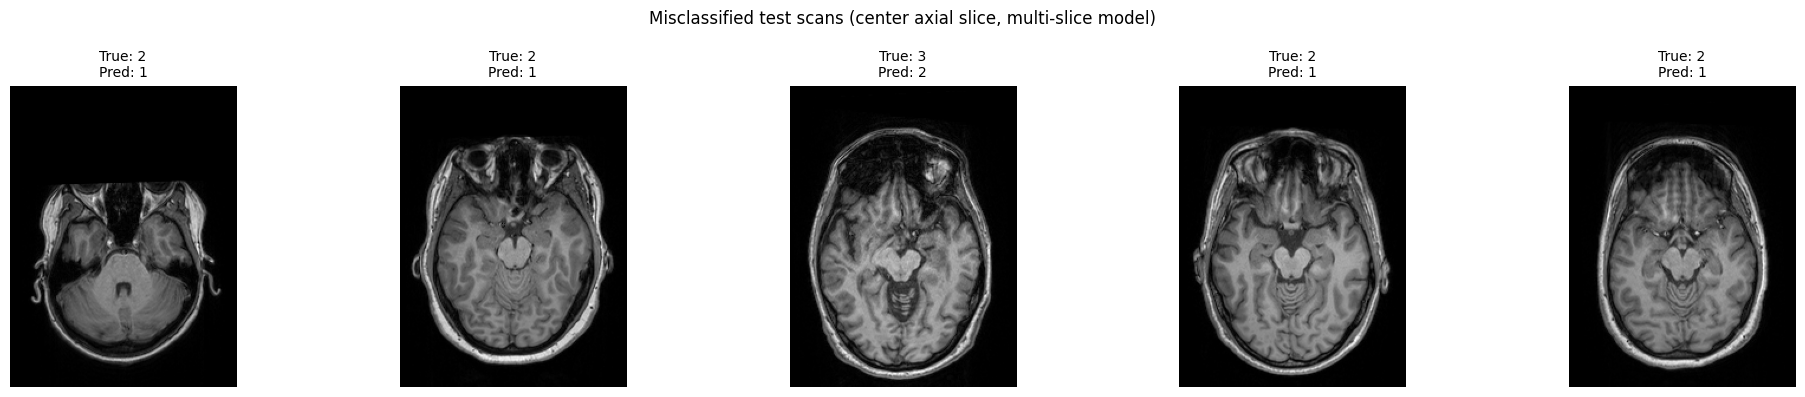

In [ ]:
misclassified_idx = np.where(test_labels_ms != test_preds_ms)[0]
print(f'{len(misclassified_idx)} misclassified out of {len(test_labels_ms)}')

show_idx = misclassified_idx[:5]

fig, axes = plt.subplots(1, len(show_idx), figsize=(4*len(show_idx), 4))
for i, idx in enumerate(show_idx):
    row = test_df.iloc[idx]
    vol = load_volume(row['bids_name'].split('_')[0], row['bids_name'].split('acq-')[1].split('_')[0])
    axial, _, _ = central_slices(vol)

    axes[i].imshow(np.rot90(axial), cmap='gray')
    axes[i].set_title(f"True: {test_labels_ms[idx]+1}\nPred: {test_preds_ms[idx]+1}", fontsize=10)
    axes[i].axis('off')

plt.suptitle('Misclassified test scans (center axial slice, multi-slice model)')
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/misclassified_examples.png', dpi=150)
plt.show()

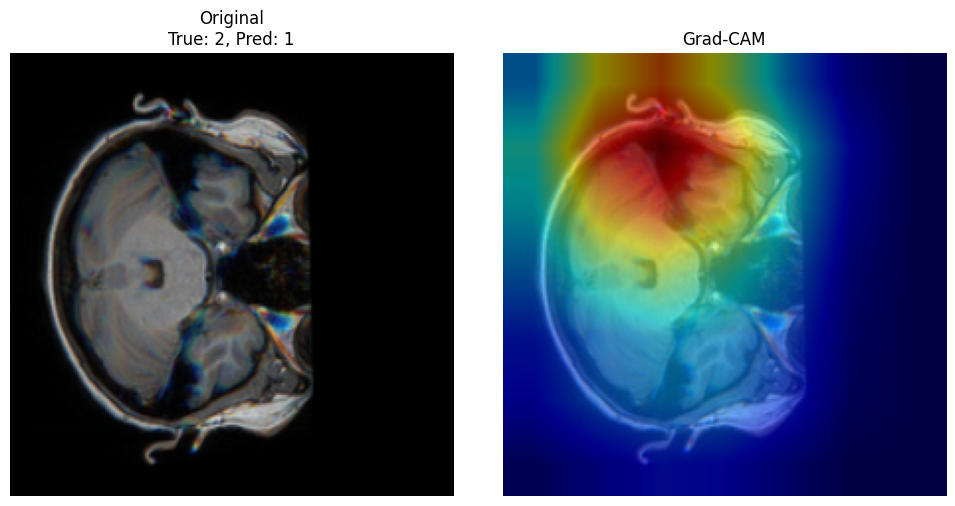

In [ ]:
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget

target_layer = [model.layer4[-1]]
cam = GradCAM(model=model, target_layers=target_layer)

idx = misclassified_idx[0]
row = test_df.iloc[idx]

img_tensor, true_label = test_dataset[idx]
input_tensor = img_tensor.unsqueeze(0).to(device)

targets = [ClassifierOutputTarget(test_preds_ms[idx])]
grayscale_cam = cam(input_tensor=input_tensor, targets=targets)[0]

img_display = img_tensor.permute(1, 2, 0).numpy()
img_display = img_display * np.array([0.229, 0.224, 0.225]) + np.array([0.485, 0.456, 0.406])
img_display = np.clip(img_display, 0, 1)

visualization = show_cam_on_image(img_display, grayscale_cam, use_rgb=True)

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(img_display)
axes[0].set_title(f"Original\nTrue: {test_labels_ms[idx]+1}, Pred: {test_preds_ms[idx]+1}")
axes[0].axis('off')
axes[1].imshow(visualization)
axes[1].set_title("Grad-CAM")
axes[1].axis('off')
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/gradcam_example.png', dpi=150)
plt.show()

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

clf = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
clf.fit(X_train_scaled, y_train)

print("Logistic regression retrained.")

Logistic regression retrained.


In [ ]:
from sklearn.metrics import roc_auc_score

# Classical models already output probabilities directly
logreg_test_proba = clf.predict_proba(X_test_scaled)
rf_test_proba = rf_clf.predict_proba(X_test)
xgb_test_proba = xgb_clf.predict_proba(X_test)

print("One-vs-rest AUROC (test set):")
print(f"Logistic Regression: {roc_auc_score(y_test, logreg_test_proba, multi_class='ovr'):.3f}")
print(f"Random Forest:       {roc_auc_score(y_test, rf_test_proba, multi_class='ovr'):.3f}")
print(f"XGBoost:              {roc_auc_score(y_test_xgb, xgb_test_proba, multi_class='ovr'):.3f}")

# For the multi-slice CNN, need to get averaged probabilities per scan (not just the final prediction)
def get_multislice_probs(df, offsets=[-10, -5, 0, 5, 10]):
    model.eval()
    all_probs = []
    all_labels = []

    with torch.no_grad():
        for _, row in df.iterrows():
            slices = []
            for offset in offsets:
                subject = row['bids_name'].split('_')[0]
                fpath = data_path / subject / 'anat' / f"{row['bids_name']}.nii.gz"
                vol = nib.load(fpath).get_fdata()
                z = vol.shape[2] // 2 + offset
                stack = np.stack([vol[:, :, z-1], vol[:, :, z], vol[:, :, z+1]], axis=-1)
                stack = stack - stack.min()
                stack = (stack / (stack.max() + 1e-8) * 255).astype(np.uint8)
                img = eval_transform(Image.fromarray(stack))
                slices.append(img)

            batch = torch.stack(slices).to(device)
            outputs = model(batch)
            probs = F.softmax(outputs, dim=1)
            avg_probs = probs.mean(dim=0).cpu().numpy()

            all_probs.append(avg_probs)
            all_labels.append(int(row['score']) - 1)

    return np.array(all_labels), np.array(all_probs)

cnn_test_labels, cnn_test_probs = get_multislice_probs(test_df)
print(f"ResNet-18 (multi-slice): {roc_auc_score(cnn_test_labels, cnn_test_probs, multi_class='ovr'):.3f}")

One-vs-rest AUROC (test set):
Logistic Regression: 0.819
Random Forest:       0.921
XGBoost:              0.922
ResNet-18 (multi-slice): 0.915


In [ ]:
class AttentionPool2d(nn.Module):
    """Learned spatial attention pooling, inspired by the self-attention
    re-weighting approach in Bakhale & Sao's MR-ART quality assessment work."""
    def __init__(self, channels):
        super().__init__()
        self.attn = nn.Conv2d(channels, 1, kernel_size=1)

    def forward(self, x):
        attn_logits = self.attn(x)  # (B, 1, H, W)
        attn_weights = F.softmax(attn_logits.flatten(2), dim=-1).view_as(attn_logits)
        pooled = (x * attn_weights).sum(dim=[2, 3])  # (B, C)
        return pooled, attn_weights

# Build attention-augmented ResNet-18
resnet_backbone = models.resnet18(weights='IMAGENET1K_V1')
feature_extractor = nn.Sequential(*list(resnet_backbone.children())[:-2])  # drop avgpool + fc

class AttentionResNet(nn.Module):
    def __init__(self, num_classes=3):
        super().__init__()
        self.features = feature_extractor
        self.attn_pool = AttentionPool2d(512)  # ResNet-18's final feature depth
        self.classifier = nn.Linear(512, num_classes)

    def forward(self, x, return_attn=False):
        feat_map = self.features(x)
        pooled, attn_weights = self.attn_pool(feat_map)
        out = self.classifier(pooled)
        if return_attn:
            return out, attn_weights
        return out

attn_model = AttentionResNet(num_classes=3).to(device)
optimizer_attn = optim.Adam(attn_model.parameters(), lr=1e-4)

print("Attention-augmented ResNet-18 built.")

Attention-augmented ResNet-18 built.


In [ ]:
best_val_acc = 0
best_state = None

for epoch in range(15):
    attn_model.train()
    running_loss = 0
    correct = 0
    total = 0

    for images, labels in train_loader_multi:
        images, labels = images.to(device), labels.to(device)
        optimizer_attn.zero_grad()
        outputs = attn_model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer_attn.step()

        running_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    train_acc = correct / total

    # check validation accuracy this epoch
    attn_model.eval()
    val_correct = 0
    val_total = 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = attn_model(images)
            _, predicted = torch.max(outputs, 1)
            val_total += labels.size(0)
            val_correct += (predicted == labels).sum().item()
    val_acc = val_correct / val_total

    print(f'Epoch {epoch+1} - Loss: {running_loss/len(train_loader_multi):.4f} - Train Acc: {train_acc:.4f} - Val Acc: {val_acc:.4f}')

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_state = attn_model.state_dict()

attn_model.load_state_dict(best_state)
print(f'\nBest validation accuracy: {best_val_acc:.4f} — restored best model weights.')

Epoch 1 - Loss: 0.6522 - Train Acc: 0.7245 - Val Acc: 0.7727
Epoch 2 - Loss: 0.5426 - Train Acc: 0.7921 - Val Acc: 0.6970
Epoch 3 - Loss: 0.5189 - Train Acc: 0.8079 - Val Acc: 0.6364
Epoch 4 - Loss: 0.4185 - Train Acc: 0.8351 - Val Acc: 0.7273
Epoch 5 - Loss: 0.3586 - Train Acc: 0.8689 - Val Acc: 0.6212
Epoch 6 - Loss: 0.2631 - Train Acc: 0.9106 - Val Acc: 0.7424
Epoch 7 - Loss: 0.2714 - Train Acc: 0.8954 - Val Acc: 0.7727
Epoch 8 - Loss: 0.2005 - Train Acc: 0.9272 - Val Acc: 0.7424
Epoch 9 - Loss: 0.2338 - Train Acc: 0.9205 - Val Acc: 0.7576
Epoch 10 - Loss: 0.1764 - Train Acc: 0.9437 - Val Acc: 0.7121
Epoch 11 - Loss: 0.1986 - Train Acc: 0.9377 - Val Acc: 0.6667
Epoch 12 - Loss: 0.1134 - Train Acc: 0.9642 - Val Acc: 0.7424
Epoch 13 - Loss: 0.0993 - Train Acc: 0.9636 - Val Acc: 0.7121
Epoch 14 - Loss: 0.1031 - Train Acc: 0.9649 - Val Acc: 0.7424
Epoch 15 - Loss: 0.0815 - Train Acc: 0.9695 - Val Acc: 0.6515

Best validation accuracy: 0.7727 — restored best model weights.


In [ ]:
# --- 1. Drive ---
from google.colab import drive
drive.mount('/content/drive')

import os
DRIVE_ROOT = '/content/drive/MyDrive/mrart_project'
DATA_DIR = f'{DRIVE_ROOT}/ds004173'
LOCAL_DATA_DIR = '/content/ds004173'
OUTPUT_DIR = f'{DRIVE_ROOT}/outputs'
os.makedirs(DRIVE_ROOT, exist_ok=True)
os.makedirs(OUTPUT_DIR, exist_ok=True)

# --- 2. Paketler ---
!pip install -q nibabel awscli grad-cam

# --- 3. Veriyi local diske kopyala ---
!mkdir -p "{LOCAL_DATA_DIR}"
!rsync -a "{DATA_DIR}/" "{LOCAL_DATA_DIR}/"

# --- 4. Veriyi yükle ---
import pandas as pd
import numpy as np
import nibabel as nib
import matplotlib.pyplot as plt
from pathlib import Path

data_path = Path(LOCAL_DATA_DIR)
participants = pd.read_csv(data_path / 'participants.tsv', sep='\t')
scores = pd.read_csv(data_path / 'derivatives' / 'scores.tsv', sep='\t')
mriqc = pd.read_csv(data_path / 'derivatives' / 'mriqc-0.16.1' / 'group_T1w.tsv', sep='\t')
merged = mriqc.merge(scores, on='bids_name', how='inner')

def load_volume(subject, acq):
    fpath = data_path / subject / 'anat' / f'{subject}_acq-{acq}_T1w.nii.gz'
    return nib.load(fpath).get_fdata()

def central_slices(vol):
    x, y, z = np.array(vol.shape) // 2
    return vol[:, :, z], vol[:, y, :], vol[x, :, :]

# --- 5. Subject-level split ---
from sklearn.model_selection import train_test_split

subjects = participants['participant_id'].unique()
train_subj, temp_subj = train_test_split(subjects, test_size=0.3, random_state=42)
val_subj, test_subj = train_test_split(temp_subj, test_size=0.5, random_state=42)

def assign_split(bids_name):
    subj = bids_name.split('_')[0]
    if subj in train_subj: return 'train'
    elif subj in val_subj: return 'val'
    else: return 'test'

merged['split'] = merged['bids_name'].apply(assign_split)
train_df = merged[merged['split'] == 'train']
val_df = merged[merged['split'] == 'val']
test_df = merged[merged['split'] == 'test']

feature_cols = [c for c in mriqc.columns if c != 'bids_name']
X_train, y_train = train_df[feature_cols], train_df['score']
X_val, y_val = val_df[feature_cols], val_df['score']
X_test, y_test = test_df[feature_cols], test_df['score']

# --- 6. Dataset sınıfları ---
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from PIL import Image
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import balanced_accuracy_score, f1_score, classification_report, confusion_matrix, roc_auc_score

class MRIQualityDataset(Dataset):
    def __init__(self, df, data_path, transform=None):
        self.df = df.reset_index(drop=True)
        self.data_path = data_path
        self.transform = transform
    def __len__(self):
        return len(self.df)
    def _get_2p5d_slice(self, bids_name):
        subject = bids_name.split('_')[0]
        fpath = self.data_path / subject / 'anat' / f'{bids_name}.nii.gz'
        vol = nib.load(fpath).get_fdata()
        z = vol.shape[2] // 2
        stack = np.stack([vol[:, :, z-1], vol[:, :, z], vol[:, :, z+1]], axis=-1)
        stack = stack - stack.min()
        return (stack / (stack.max() + 1e-8) * 255).astype(np.uint8)
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = Image.fromarray(self._get_2p5d_slice(row['bids_name']))
        if self.transform: img = self.transform(img)
        return img, int(row['score']) - 1

class MultiSliceMRIDataset(Dataset):
    def __init__(self, df, data_path, transform=None, offsets=[-10, -5, 0, 5, 10]):
        self.samples = []
        for _, row in df.iterrows():
            for offset in offsets:
                self.samples.append((row['bids_name'], int(row['score']) - 1, offset))
        self.data_path = data_path
        self.transform = transform
    def __len__(self):
        return len(self.samples)
    def _get_2p5d_slice(self, bids_name, offset):
        subject = bids_name.split('_')[0]
        fpath = self.data_path / subject / 'anat' / f'{bids_name}.nii.gz'
        vol = nib.load(fpath).get_fdata()
        z = vol.shape[2] // 2 + offset
        stack = np.stack([vol[:, :, z-1], vol[:, :, z], vol[:, :, z+1]], axis=-1)
        stack = stack - stack.min()
        return (stack / (stack.max() + 1e-8) * 255).astype(np.uint8)
    def __getitem__(self, idx):
        bids_name, label, offset = self.samples[idx]
        img = Image.fromarray(self._get_2p5d_slice(bids_name, offset))
        if self.transform: img = self.transform(img)
        return img, label

train_transform = transforms.Compose([
    transforms.Resize((224, 224)), transforms.RandomHorizontalFlip(),
    transforms.ToTensor(), transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])
eval_transform = transforms.Compose([
    transforms.Resize((224, 224)), transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

train_dataset_multi = MultiSliceMRIDataset(train_df, data_path, transform=train_transform)
train_loader_multi = DataLoader(train_dataset_multi, batch_size=16, shuffle=True, num_workers=2)
val_dataset = MRIQualityDataset(val_df, data_path, transform=eval_transform)
test_dataset = MRIQualityDataset(test_df, data_path, transform=eval_transform)
val_loader = DataLoader(val_dataset, batch_size=16, shuffle=False, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False, num_workers=2)

# --- 7. Modeli yeniden eğit ---
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Using device:', device)

model = models.resnet18(weights='IMAGENET1K_V1')
model.fc = nn.Linear(model.fc.in_features, 3)
model = model.to(device)

train_labels = (train_df['score'] - 1).values
class_weights = compute_class_weight('balanced', classes=np.array([0, 1, 2]), y=train_labels)
class_weights = torch.tensor(class_weights, dtype=torch.float32).to(device)
print('Class weights:', class_weights)

criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = optim.Adam(model.parameters(), lr=1e-4)

for epoch in range(10):
    model.train()
    running_loss, correct, total = 0, 0, 0
    for images, labels in train_loader_multi:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
    print(f'Epoch {epoch+1}/10 - Loss: {running_loss/len(train_loader_multi):.4f} - Train Acc: {correct/total:.4f}')

# --- 8. BU SEFER AĞIRLIKLARI KAYDET (bir daha kaybetmemek için) ---
torch.save(model.state_dict(), f'{OUTPUT_DIR}/resnet18_multislice_weights.pth')
print("Model ağırlıkları Drive'a kaydedildi.")

# --- 9. Grad-CAM için hazırlık ---
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget

target_layer = [model.layer4[-1]]
cam = GradCAM(model=model, target_layers=target_layer)

print("Hazır — şimdi evaluate_multislice ve Grad-CAM hücrelerini çalıştırabilirsin.")

Mounted at /content/drive
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.5/44.5 kB 462.4 kB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 20.2/20.2 MB 49.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 570.5/570.5 kB 48.7 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
sphinx 8.2.3 requires docutils<0.22,>=0.20, but you have docutils 0.19 which is incompatible.
Using device: cuda
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 213MB/s]


Class weights: tensor([1.1439, 1.3074, 0.7348], device='cuda:0')
Epoch 1/10 - Loss: 0.7154 - Train Acc: 0.6854
Epoch 2/10 - Loss: 0.5319 - Train Acc: 0.7834


In [ ]:
def evaluate_multislice(df, offsets=[-10, -5, 0, 5, 10]):
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for _, row in df.iterrows():
            slices = []
            for offset in offsets:
                subject = row['bids_name'].split('_')[0]
                fpath = data_path / subject / 'anat' / f"{row['bids_name']}.nii.gz"
                vol = nib.load(fpath).get_fdata()
                z = vol.shape[2] // 2 + offset
                stack = np.stack([vol[:, :, z-1], vol[:, :, z], vol[:, :, z+1]], axis=-1)
                stack = stack - stack.min()
                stack = (stack / (stack.max() + 1e-8) * 255).astype(np.uint8)
                img = eval_transform(Image.fromarray(stack))
                slices.append(img)

            batch = torch.stack(slices).to(device)
            outputs = model(batch)
            probs = F.softmax(outputs, dim=1)
            avg_probs = probs.mean(dim=0)
            pred = torch.argmax(avg_probs).item()

            all_preds.append(pred)
            all_labels.append(int(row['score']) - 1)

    return np.array(all_labels), np.array(all_preds)

test_labels_ms, test_preds_ms = evaluate_multislice(test_df)
print("evaluate_multislice tamamlandı.")
print(f"Yanlış tahmin sayısı: {(test_labels_ms != test_preds_ms).sum()} / {len(test_labels_ms)}")

NameError: name 'test_df' is not defined

In [ ]:
correct_idx = np.where(test_labels_ms == test_preds_ms)[0][0]
wrong_idx = np.where(test_labels_ms != test_preds_ms)[0][0]

fig, axes = plt.subplots(2, 2, figsize=(10, 10))

for row, idx in enumerate([correct_idx, wrong_idx]):
    img_tensor, _ = test_dataset[idx]
    input_tensor = img_tensor.unsqueeze(0).to(device)
    targets = [ClassifierOutputTarget(test_preds_ms[idx])]
    grayscale_cam = cam(input_tensor=input_tensor, targets=targets)[0]

    img_display = img_tensor.permute(1, 2, 0).numpy()
    img_display = img_display * np.array([0.229, 0.224, 0.225]) + np.array([0.485, 0.456, 0.406])
    img_display = np.clip(img_display, 0, 1)
    visualization = show_cam_on_image(img_display, grayscale_cam, use_rgb=True)

    label = "Doğru Tahmin" if row == 0 else "Yanlış Tahmin"
    axes[row, 0].imshow(img_display)
    axes[row, 0].set_title(f"{label}\nGerçek: {test_labels_ms[idx]+1}, Tahmin: {test_preds_ms[idx]+1}")
    axes[row, 0].axis('off')
    axes[row, 1].imshow(visualization)
    axes[row, 1].set_title("Grad-CAM")
    axes[row, 1].axis('off')

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/gradcam_correct_vs_wrong.png', dpi=150)
plt.show()
print("Grad-CAM karşılaştırması Drive'a kaydedildi.")

In [ ]:
# --- 1. Drive ---
from google.colab import drive
drive.mount('/content/drive')

import os
DRIVE_ROOT = '/content/drive/MyDrive/mrart_project'
DATA_DIR = f'{DRIVE_ROOT}/ds004173'
LOCAL_DATA_DIR = '/content/ds004173'
OUTPUT_DIR = f'{DRIVE_ROOT}/outputs'
os.makedirs(DRIVE_ROOT, exist_ok=True)
os.makedirs(OUTPUT_DIR, exist_ok=True)

# --- 2. Paketler ---
!pip install -q nibabel awscli grad-cam tqdm

# --- 3. Veriyi local diske kopyala ---
!mkdir -p "{LOCAL_DATA_DIR}"
!rsync -a "{DATA_DIR}/" "{LOCAL_DATA_DIR}/"

# --- 4. Veriyi yükle ---
import pandas as pd
import numpy as np
import nibabel as nib
import matplotlib.pyplot as plt
from pathlib import Path

data_path = Path(LOCAL_DATA_DIR)
participants = pd.read_csv(data_path / 'participants.tsv', sep='\t')
scores = pd.read_csv(data_path / 'derivatives' / 'scores.tsv', sep='\t')
mriqc = pd.read_csv(data_path / 'derivatives' / 'mriqc-0.16.1' / 'group_T1w.tsv', sep='\t')
merged = mriqc.merge(scores, on='bids_name', how='inner')

def load_volume(subject, acq):
    fpath = data_path / subject / 'anat' / f'{subject}_acq-{acq}_T1w.nii.gz'
    return nib.load(fpath).get_fdata()

def central_slices(vol):
    x, y, z = np.array(vol.shape) // 2
    return vol[:, :, z], vol[:, y, :], vol[x, :, :]

# --- 5. Subject-level split ---
from sklearn.model_selection import train_test_split

subjects = participants['participant_id'].unique()
train_subj, temp_subj = train_test_split(subjects, test_size=0.3, random_state=42)
val_subj, test_subj = train_test_split(temp_subj, test_size=0.5, random_state=42)

def assign_split(bids_name):
    subj = bids_name.split('_')[0]
    if subj in train_subj: return 'train'
    elif subj in val_subj: return 'val'
    else: return 'test'

merged['split'] = merged['bids_name'].apply(assign_split)
train_df = merged[merged['split'] == 'train']
val_df = merged[merged['split'] == 'val']
test_df = merged[merged['split'] == 'test']

feature_cols = [c for c in mriqc.columns if c != 'bids_name']
X_train, y_train = train_df[feature_cols], train_df['score']
X_val, y_val = val_df[feature_cols], val_df['score']
X_test, y_test = test_df[feature_cols], test_df['score']

# --- 6. Dataset sınıfları ---
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from PIL import Image
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import balanced_accuracy_score, f1_score, classification_report, confusion_matrix, roc_auc_score
from tqdm.notebook import tqdm

class MRIQualityDataset(Dataset):
    def __init__(self, df, data_path, transform=None):
        self.df = df.reset_index(drop=True)
        self.data_path = data_path
        self.transform = transform
    def __len__(self):
        return len(self.df)
    def _get_2p5d_slice(self, bids_name):
        subject = bids_name.split('_')[0]
        fpath = self.data_path / subject / 'anat' / f'{bids_name}.nii.gz'
        vol = nib.load(fpath).get_fdata()
        z = vol.shape[2] // 2
        stack = np.stack([vol[:, :, z-1], vol[:, :, z], vol[:, :, z+1]], axis=-1)
        stack = stack - stack.min()
        return (stack / (stack.max() + 1e-8) * 255).astype(np.uint8)
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = Image.fromarray(self._get_2p5d_slice(row['bids_name']))
        if self.transform: img = self.transform(img)
        return img, int(row['score']) - 1

class MultiSliceMRIDataset(Dataset):
    def __init__(self, df, data_path, transform=None, offsets=[-10, -5, 0, 5, 10]):
        self.samples = []
        for _, row in df.iterrows():
            for offset in offsets:
                self.samples.append((row['bids_name'], int(row['score']) - 1, offset))
        self.data_path = data_path
        self.transform = transform
    def __len__(self):
        return len(self.samples)
    def _get_2p5d_slice(self, bids_name, offset):
        subject = bids_name.split('_')[0]
        fpath = self.data_path / subject / 'anat' / f'{bids_name}.nii.gz'
        vol = nib.load(fpath).get_fdata()
        z = vol.shape[2] // 2 + offset
        stack = np.stack([vol[:, :, z-1], vol[:, :, z], vol[:, :, z+1]], axis=-1)
        stack = stack - stack.min()
        return (stack / (stack.max() + 1e-8) * 255).astype(np.uint8)
    def __getitem__(self, idx):
        bids_name, label, offset = self.samples[idx]
        img = Image.fromarray(self._get_2p5d_slice(bids_name, offset))
        if self.transform: img = self.transform(img)
        return img, label

train_transform = transforms.Compose([
    transforms.Resize((224, 224)), transforms.RandomHorizontalFlip(),
    transforms.ToTensor(), transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])
eval_transform = transforms.Compose([
    transforms.Resize((224, 224)), transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

train_dataset_multi = MultiSliceMRIDataset(train_df, data_path, transform=train_transform)
train_loader_multi = DataLoader(train_dataset_multi, batch_size=16, shuffle=True, num_workers=2)
val_dataset = MRIQualityDataset(val_df, data_path, transform=eval_transform)
test_dataset = MRIQualityDataset(test_df, data_path, transform=eval_transform)
val_loader = DataLoader(val_dataset, batch_size=16, shuffle=False, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False, num_workers=2)

# --- 7. Model kurulumu ---
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Using device:', device)

model = models.resnet18(weights='IMAGENET1K_V1')
model.fc = nn.Linear(model.fc.in_features, 3)
model = model.to(device)

train_labels = (train_df['score'] - 1).values
class_weights = compute_class_weight('balanced', classes=np.array([0, 1, 2]), y=train_labels)
class_weights = torch.tensor(class_weights, dtype=torch.float32).to(device)
print('Class weights:', class_weights)

criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = optim.Adam(model.parameters(), lr=1e-4)

# --- 8. Eğitim (canlı ilerleme çubuğuyla) ---
num_epochs = 10

for epoch in range(num_epochs):
    model.train()
    running_loss, correct, total = 0, 0, 0

    progress_bar = tqdm(train_loader_multi, desc=f'Epoch {epoch+1}/{num_epochs}')
    for images, labels in progress_bar:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

        progress_bar.set_postfix(loss=loss.item(), acc=correct/total)

    print(f'Epoch {epoch+1}/{num_epochs} - Loss: {running_loss/len(train_loader_multi):.4f} - Train Acc: {correct/total:.4f}')

# --- 9. Ağırlıkları kaydet ---
torch.save(model.state_dict(), f'{OUTPUT_DIR}/resnet18_multislice_weights.pth')
print("Model ağırlıkları Drive'a kaydedildi.")

# --- 10. Grad-CAM hazırlık ---
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget

target_layer = [model.layer4[-1]]
cam = GradCAM(model=model, target_layers=target_layer)

print("Hazır — şimdi evaluate_multislice ve Grad-CAM hücrelerini çalıştırabilirsin.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Using device: cuda
Class weights: tensor([1.1439, 1.3074, 0.7348], device='cuda:0')


Epoch 1/10:   0%|          | 0/95 [00:00<?, ?it/s]

Epoch 1/10 - Loss: 0.7278 - Train Acc: 0.6682


Epoch 2/10:   0%|          | 0/95 [00:00<?, ?it/s]

Epoch 2/10 - Loss: 0.5480 - Train Acc: 0.7808


...

Epoch 8/10 - Loss: 0.1666 - Train Acc: 0.9411


Epoch 9/10:   0%|          | 0/95 [00:00<?, ?it/s]

Epoch 9/10 - Loss: 0.1478 - Train Acc: 0.9490


Epoch 10/10:   0%|          | 0/95 [00:00<?, ?it/s]

Epoch 10/10 - Loss: 0.1314 - Train Acc: 0.9503
Model ağırlıkları Drive'a kaydedildi.
Hazır — şimdi evaluate_multislice ve Grad-CAM hücrelerini çalıştırabilirsin.


In [ ]:
correct_idx = np.where(test_labels_ms == test_preds_ms)[0][0]
wrong_idx = np.where(test_labels_ms != test_preds_ms)[0][0]

fig, axes = plt.subplots(2, 2, figsize=(10, 10))

for row, idx in enumerate([correct_idx, wrong_idx]):
    img_tensor, _ = test_dataset[idx]
    input_tensor = img_tensor.unsqueeze(0).to(device)
    targets = [ClassifierOutputTarget(test_preds_ms[idx])]
    grayscale_cam = cam(input_tensor=input_tensor, targets=targets)[0]

    img_display = img_tensor.permute(1, 2, 0).numpy()
    img_display = img_display * np.array([0.229, 0.224, 0.225]) + np.array([0.485, 0.456, 0.406])
    img_display = np.clip(img_display, 0, 1)
    visualization = show_cam_on_image(img_display, grayscale_cam, use_rgb=True)

    label = "Doğru Tahmin" if row == 0 else "Yanlış Tahmin"
    axes[row, 0].imshow(img_display)
    axes[row, 0].set_title(f"{label}\nGerçek: {test_labels_ms[idx]+1}, Tahmin: {test_preds_ms[idx]+1}")
    axes[row, 0].axis('off')
    axes[row, 1].imshow(visualization)
    axes[row, 1].set_title("Grad-CAM")
    axes[row, 1].axis('off')

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/gradcam_correct_vs_wrong.png', dpi=150)
plt.show()
print("Grad-CAM karşılaştırması Drive'a kaydedildi.")

NameError: name 'test_labels_ms' is not defined

In [ ]:
def evaluate_multislice(df, offsets=[-10, -5, 0, 5, 10]):
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for _, row in df.iterrows():
            slices = []
            for offset in offsets:
                subject = row['bids_name'].split('_')[0]
                fpath = data_path / subject / 'anat' / f"{row['bids_name']}.nii.gz"
                vol = nib.load(fpath).get_fdata()
                z = vol.shape[2] // 2 + offset
                stack = np.stack([vol[:, :, z-1], vol[:, :, z], vol[:, :, z+1]], axis=-1)
                stack = stack - stack.min()
                stack = (stack / (stack.max() + 1e-8) * 255).astype(np.uint8)
                img = eval_transform(Image.fromarray(stack))
                slices.append(img)

            batch = torch.stack(slices).to(device)
            outputs = model(batch)
            probs = F.softmax(outputs, dim=1)
            avg_probs = probs.mean(dim=0)
            pred = torch.argmax(avg_probs).item()

            all_preds.append(pred)
            all_labels.append(int(row['score']) - 1)

    return np.array(all_labels), np.array(all_preds)

test_labels_ms, test_preds_ms = evaluate_multislice(test_df)
print("Tamamlandı.")
print(f"Yanlış tahmin sayısı: {(test_labels_ms != test_preds_ms).sum()} / {len(test_labels_ms)}")

Tamamlandı.
Yanlış tahmin sayısı: 13 / 68


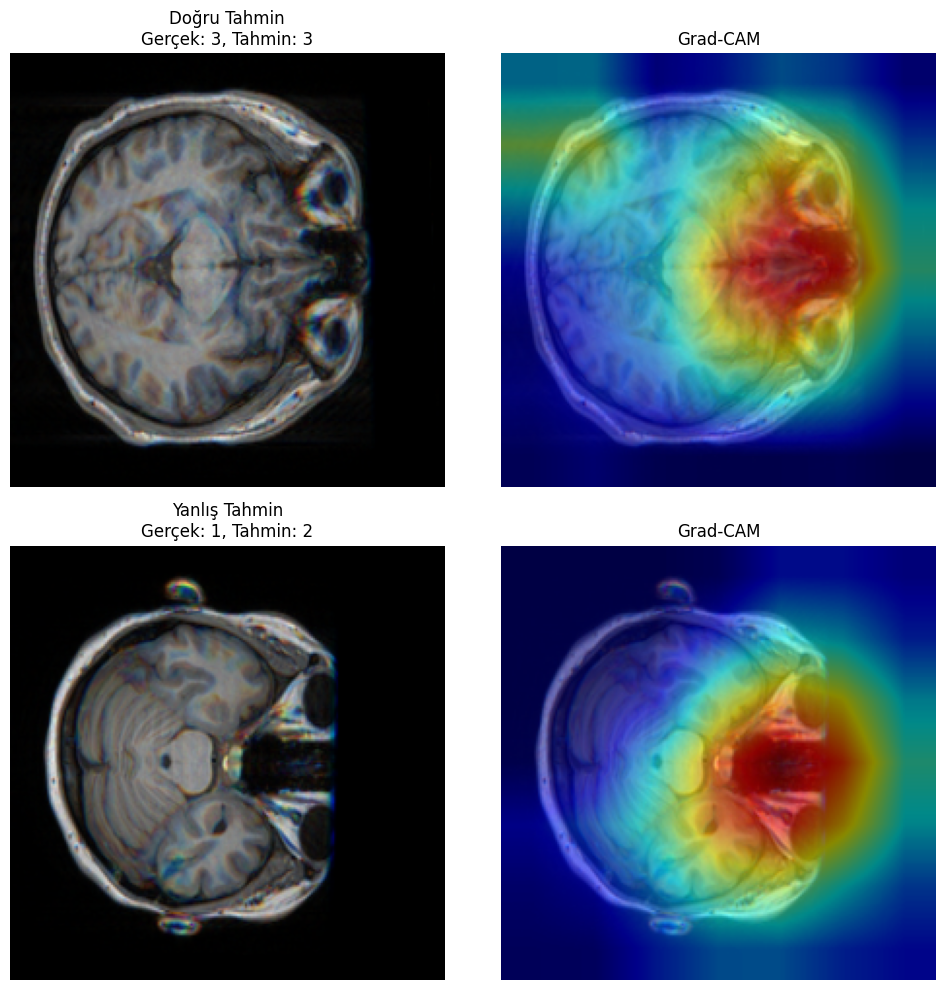

Grad-CAM karşılaştırması Drive'a kaydedildi.


In [ ]:
correct_idx = np.where(test_labels_ms == test_preds_ms)[0][0]
wrong_idx = np.where(test_labels_ms != test_preds_ms)[0][0]

fig, axes = plt.subplots(2, 2, figsize=(10, 10))

for row, idx in enumerate([correct_idx, wrong_idx]):
    img_tensor, _ = test_dataset[idx]
    input_tensor = img_tensor.unsqueeze(0).to(device)
    targets = [ClassifierOutputTarget(test_preds_ms[idx])]
    grayscale_cam = cam(input_tensor=input_tensor, targets=targets)[0]

    img_display = img_tensor.permute(1, 2, 0).numpy()
    img_display = img_display * np.array([0.229, 0.224, 0.225]) + np.array([0.485, 0.456, 0.406])
    img_display = np.clip(img_display, 0, 1)
    visualization = show_cam_on_image(img_display, grayscale_cam, use_rgb=True)

    label = "Doğru Tahmin" if row == 0 else "Yanlış Tahmin"
    axes[row, 0].imshow(img_display)
    axes[row, 0].set_title(f"{label}\nGerçek: {test_labels_ms[idx]+1}, Tahmin: {test_preds_ms[idx]+1}")
    axes[row, 0].axis('off')
    axes[row, 1].imshow(visualization)
    axes[row, 1].set_title("Grad-CAM")
    axes[row, 1].axis('off')

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/gradcam_correct_vs_wrong.png', dpi=150)
plt.show()
print("Grad-CAM karşılaştırması Drive'a kaydedildi.")

In [ ]:
wrong_idx_all = np.where(test_labels_ms != test_preds_ms)[0]
print(f"Toplam yanlış tahmin: {len(wrong_idx_all)}")

# Her (gerçek, tahmin) kombinasyonundan en fazla 1 örnek al, çeşitlilik için
seen_combos = set()
diverse_wrong = []
for idx in wrong_idx_all:
    combo = (test_labels_ms[idx], test_preds_ms[idx])
    if combo not in seen_combos:
        seen_combos.add(combo)
        diverse_wrong.append(idx)

print(f"Farklı kombinasyon sayısı: {len(diverse_wrong)}")
for idx in diverse_wrong:
    print(f"  Gerçek: {test_labels_ms[idx]+1}, Tahmin: {test_preds_ms[idx]+1}")

Toplam yanlış tahmin: 13
Farklı kombinasyon sayısı: 3
  Gerçek: 1, Tahmin: 2
  Gerçek: 2, Tahmin: 1
  Gerçek: 2, Tahmin: 3


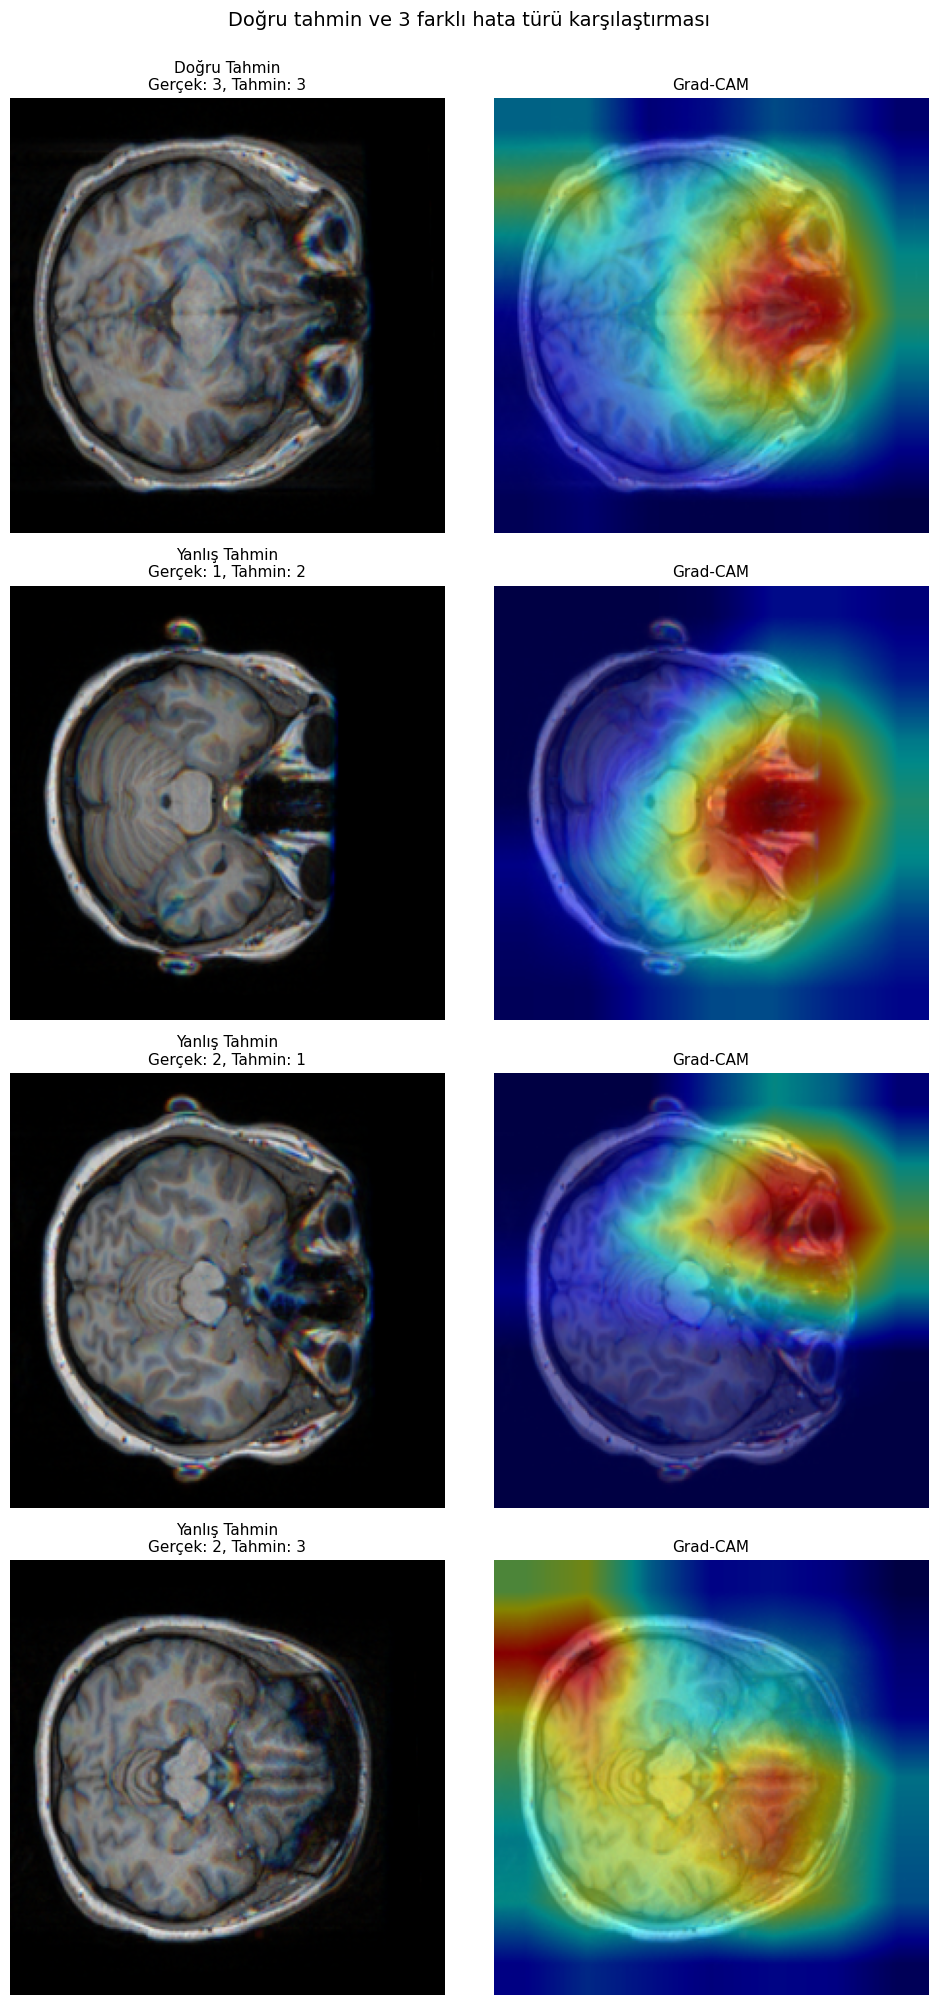

Kaydedildi: gradcam_all_error_types.png


In [ ]:
fig, axes = plt.subplots(4, 2, figsize=(10, 20))

# Karşılaştırma için 1 doğru tahmin ekleyelim
correct_idx = np.where(test_labels_ms == test_preds_ms)[0][0]
examples = [(correct_idx, "Doğru Tahmin")] + [(idx, "Yanlış Tahmin") for idx in diverse_wrong]

for row, (idx, label) in enumerate(examples):
    img_tensor, _ = test_dataset[idx]
    input_tensor = img_tensor.unsqueeze(0).to(device)
    targets = [ClassifierOutputTarget(test_preds_ms[idx])]
    grayscale_cam = cam(input_tensor=input_tensor, targets=targets)[0]

    img_display = img_tensor.permute(1, 2, 0).numpy()
    img_display = img_display * np.array([0.229, 0.224, 0.225]) + np.array([0.485, 0.456, 0.406])
    img_display = np.clip(img_display, 0, 1)
    visualization = show_cam_on_image(img_display, grayscale_cam, use_rgb=True)

    axes[row, 0].imshow(img_display)
    axes[row, 0].set_title(f"{label}\nGerçek: {test_labels_ms[idx]+1}, Tahmin: {test_preds_ms[idx]+1}", fontsize=11)
    axes[row, 0].axis('off')
    axes[row, 1].imshow(visualization)
    axes[row, 1].set_title("Grad-CAM", fontsize=11)
    axes[row, 1].axis('off')

plt.suptitle("Doğru tahmin ve 3 farklı hata türü karşılaştırması", fontsize=14, y=1.0)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/gradcam_all_error_types.png', dpi=150, bbox_inches='tight')
plt.show()
print("Kaydedildi: gradcam_all_error_types.png")

In [ ]:
from sklearn.metrics import roc_auc_score

def get_multislice_probs(df, offsets=[-10, -5, 0, 5, 10]):
    model.eval()
    all_probs = []
    all_labels = []

    with torch.no_grad():
        for _, row in df.iterrows():
            slices = []
            for offset in offsets:
                subject = row['bids_name'].split('_')[0]
                fpath = data_path / subject / 'anat' / f"{row['bids_name']}.nii.gz"
                vol = nib.load(fpath).get_fdata()
                z = vol.shape[2] // 2 + offset
                stack = np.stack([vol[:, :, z-1], vol[:, :, z], vol[:, :, z+1]], axis=-1)
                stack = stack - stack.min()
                stack = (stack / (stack.max() + 1e-8) * 255).astype(np.uint8)
                img = eval_transform(Image.fromarray(stack))
                slices.append(img)

            batch = torch.stack(slices).to(device)
            outputs = model(batch)
            probs = F.softmax(outputs, dim=1)
            avg_probs = probs.mean(dim=0).cpu().numpy()

            all_probs.append(avg_probs)
            all_labels.append(int(row['score']) - 1)

    return np.array(all_labels), np.array(all_probs)

cnn_test_labels, cnn_test_probs = get_multislice_probs(test_df)
auc = roc_auc_score(cnn_test_labels, cnn_test_probs, multi_class='ovr')
print(f"ResNet-18 (multi-slice, yeniden eğitilmiş) — One-vs-rest AUROC: {auc:.3f}")

ResNet-18 (multi-slice, yeniden eğitilmiş) — One-vs-rest AUROC: 0.908


Mounted at /content/drive
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.5/44.5 kB 471.6 kB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 20.2/20.2 MB 49.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 570.5/570.5 kB 49.7 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
sphinx 8.2.3 requires docutils<0.22,>=0.20, but you have docutils 0.19 which is incompatible.
 15,525,041,367 100%    5.55MB/s    0:44:27 (xfr#2052, to-chk=0/2648)
Kopyalama tamamlandı.
Using device: cuda
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 237MB/s]


Class weights: tensor([1.1439, 1.3074, 0.7348], device='cuda:0')


Epoch 1/10:   0%|          | 0/95 [00:00<?, ?it/s]

Epoch 1/10 — Train Loss: 0.7073 Acc: 0.6907 | Val Loss: 0.5266 Acc: 0.6970


...

Epoch 8/10 — Train Loss: 0.1481 Acc: 0.9503 | Val Loss: 0.8152 Acc: 0.6970


Epoch 9/10:   0%|          | 0/95 [00:00<?, ?it/s]

Epoch 9/10 — Train Loss: 0.1490 Acc: 0.9497 | Val Loss: 0.9081 Acc: 0.6667


Epoch 10/10:   0%|          | 0/95 [00:00<?, ?it/s]

Epoch 10/10 — Train Loss: 0.1265 Acc: 0.9543 | Val Loss: 0.7790 Acc: 0.7121

Eğitim geçmişi kaydedildi:
   epoch  train_loss  train_acc  val_loss   val_acc
0      1    0.707336   0.690728  0.526643  0.696970
1      2    0.502716   0.801325  0.655218  0.727273
2      3    0.396695   0.853642  0.570989  0.848485
3      4    0.373164   0.855629  0.720093  0.696970
4      5    0.273203   0.897351  1.362031  0.606061
5      6    0.223630   0.917881  0.882299  0.712121
6      7    0.192920   0.933113  0.648079  0.757576
7      8    0.148064   0.950331  0.815163  0.696970
8      9    0.148985   0.949669  0.908068  0.666667
9     10    0.126498   0.954305  0.779014  0.712121


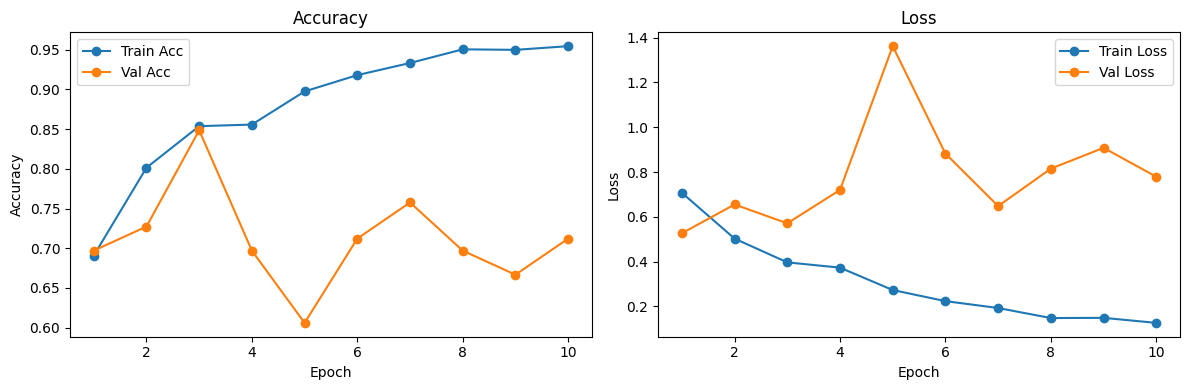

Model ağırlıkları ve eğrisi Drive'a kaydedildi.
Hazır — evaluate_multislice ve Grad-CAM hücrelerini çalıştırabilirsin.


In [1]:
# --- 1. Drive ---
from google.colab import drive
drive.mount('/content/drive')

import os
DRIVE_ROOT = '/content/drive/MyDrive/mrart_project'
DATA_DIR = f'{DRIVE_ROOT}/ds004173'
LOCAL_DATA_DIR = '/content/ds004173'
OUTPUT_DIR = f'{DRIVE_ROOT}/outputs'
os.makedirs(DRIVE_ROOT, exist_ok=True)
os.makedirs(OUTPUT_DIR, exist_ok=True)

# --- 2. Paketler ---
!pip install -q nibabel awscli grad-cam tqdm

# --- 3. Veriyi local diske kopyala ---
!mkdir -p "{LOCAL_DATA_DIR}"
!rsync -a --info=progress2 "{DATA_DIR}/" "{LOCAL_DATA_DIR}/"
print("Kopyalama tamamlandı.")

# --- 4. Veriyi yükle ---
import pandas as pd
import numpy as np
import nibabel as nib
import matplotlib.pyplot as plt
from pathlib import Path

data_path = Path(LOCAL_DATA_DIR)
participants = pd.read_csv(data_path / 'participants.tsv', sep='\t')
scores = pd.read_csv(data_path / 'derivatives' / 'scores.tsv', sep='\t')
mriqc = pd.read_csv(data_path / 'derivatives' / 'mriqc-0.16.1' / 'group_T1w.tsv', sep='\t')
merged = mriqc.merge(scores, on='bids_name', how='inner')

def load_volume(subject, acq):
    fpath = data_path / subject / 'anat' / f'{subject}_acq-{acq}_T1w.nii.gz'
    return nib.load(fpath).get_fdata()

def central_slices(vol):
    x, y, z = np.array(vol.shape) // 2
    return vol[:, :, z], vol[:, y, :], vol[x, :, :]

# --- 5. Subject-level split ---
from sklearn.model_selection import train_test_split

subjects = participants['participant_id'].unique()
train_subj, temp_subj = train_test_split(subjects, test_size=0.3, random_state=42)
val_subj, test_subj = train_test_split(temp_subj, test_size=0.5, random_state=42)

def assign_split(bids_name):
    subj = bids_name.split('_')[0]
    if subj in train_subj: return 'train'
    elif subj in val_subj: return 'val'
    else: return 'test'

merged['split'] = merged['bids_name'].apply(assign_split)
train_df = merged[merged['split'] == 'train']
val_df = merged[merged['split'] == 'val']
test_df = merged[merged['split'] == 'test']

feature_cols = [c for c in mriqc.columns if c != 'bids_name']
X_train, y_train = train_df[feature_cols], train_df['score']
X_val, y_val = val_df[feature_cols], val_df['score']
X_test, y_test = test_df[feature_cols], test_df['score']

# --- 6. Dataset sınıfları ---
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from PIL import Image
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import balanced_accuracy_score, f1_score, classification_report, confusion_matrix, roc_auc_score
from tqdm.notebook import tqdm

class MRIQualityDataset(Dataset):
    def __init__(self, df, data_path, transform=None):
        self.df = df.reset_index(drop=True)
        self.data_path = data_path
        self.transform = transform
    def __len__(self):
        return len(self.df)
    def _get_2p5d_slice(self, bids_name):
        subject = bids_name.split('_')[0]
        fpath = self.data_path / subject / 'anat' / f'{bids_name}.nii.gz'
        vol = nib.load(fpath).get_fdata()
        z = vol.shape[2] // 2
        stack = np.stack([vol[:, :, z-1], vol[:, :, z], vol[:, :, z+1]], axis=-1)
        stack = stack - stack.min()
        return (stack / (stack.max() + 1e-8) * 255).astype(np.uint8)
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = Image.fromarray(self._get_2p5d_slice(row['bids_name']))
        if self.transform: img = self.transform(img)
        return img, int(row['score']) - 1

class MultiSliceMRIDataset(Dataset):
    def __init__(self, df, data_path, transform=None, offsets=[-10, -5, 0, 5, 10]):
        self.samples = []
        for _, row in df.iterrows():
            for offset in offsets:
                self.samples.append((row['bids_name'], int(row['score']) - 1, offset))
        self.data_path = data_path
        self.transform = transform
    def __len__(self):
        return len(self.samples)
    def _get_2p5d_slice(self, bids_name, offset):
        subject = bids_name.split('_')[0]
        fpath = self.data_path / subject / 'anat' / f'{bids_name}.nii.gz'
        vol = nib.load(fpath).get_fdata()
        z = vol.shape[2] // 2 + offset
        stack = np.stack([vol[:, :, z-1], vol[:, :, z], vol[:, :, z+1]], axis=-1)
        stack = stack - stack.min()
        return (stack / (stack.max() + 1e-8) * 255).astype(np.uint8)
    def __getitem__(self, idx):
        bids_name, label, offset = self.samples[idx]
        img = Image.fromarray(self._get_2p5d_slice(bids_name, offset))
        if self.transform: img = self.transform(img)
        return img, label

train_transform = transforms.Compose([
    transforms.Resize((224, 224)), transforms.RandomHorizontalFlip(),
    transforms.ToTensor(), transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])
eval_transform = transforms.Compose([
    transforms.Resize((224, 224)), transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

train_dataset_multi = MultiSliceMRIDataset(train_df, data_path, transform=train_transform)
train_loader_multi = DataLoader(train_dataset_multi, batch_size=16, shuffle=True, num_workers=2)
val_dataset = MRIQualityDataset(val_df, data_path, transform=eval_transform)
test_dataset = MRIQualityDataset(test_df, data_path, transform=eval_transform)
val_loader = DataLoader(val_dataset, batch_size=16, shuffle=False, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False, num_workers=2)

# --- 7. Model kurulumu ---
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Using device:', device)

model = models.resnet18(weights='IMAGENET1K_V1')
model.fc = nn.Linear(model.fc.in_features, 3)
model = model.to(device)

train_labels = (train_df['score'] - 1).values
class_weights = compute_class_weight('balanced', classes=np.array([0, 1, 2]), y=train_labels)
class_weights = torch.tensor(class_weights, dtype=torch.float32).to(device)
print('Class weights:', class_weights)

criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = optim.Adam(model.parameters(), lr=1e-4)

# --- 8. Val değerlendirme fonksiyonu (her epoch sonunda kullanılacak) ---
def evaluate_epoch(loader):
    model.eval()
    running_loss, correct, total = 0, 0, 0
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            running_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    return running_loss / len(loader), correct / total

# --- 9. Eğitim: her epoch train + val ölçüp kaydediyoruz ---
num_epochs = 10
history = []

for epoch in range(num_epochs):
    model.train()
    running_loss, correct, total = 0, 0, 0

    progress_bar = tqdm(train_loader_multi, desc=f'Epoch {epoch+1}/{num_epochs}')
    for images, labels in progress_bar:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
        progress_bar.set_postfix(loss=loss.item(), acc=correct/total)

    train_loss = running_loss / len(train_loader_multi)
    train_acc = correct / total

    val_loss, val_acc = evaluate_epoch(val_loader)

    print(f'Epoch {epoch+1}/{num_epochs} — Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | Val Loss: {val_loss:.4f} Acc: {val_acc:.4f}')

    history.append({
        'epoch': epoch + 1,
        'train_loss': train_loss, 'train_acc': train_acc,
        'val_loss': val_loss, 'val_acc': val_acc
    })

    # Her epoch sonunda ağırlıkları kaydet (üzerine yazarak) — bağlantı koparsa son epoch kaybolmasın
    torch.save(model.state_dict(), f'{OUTPUT_DIR}/resnet18_multislice_weights.pth')

# --- 10. Epoch geçmişini CSV olarak kaydet ---
history_df = pd.DataFrame(history)
history_df.to_csv(f'{OUTPUT_DIR}/training_history.csv', index=False)
print("\nEğitim geçmişi kaydedildi:")
print(history_df)

# --- 11. Train vs Val eğrisini çiz (overfitting kanıtı) ---
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history_df['epoch'], history_df['train_acc'], label='Train Acc', marker='o')
axes[0].plot(history_df['epoch'], history_df['val_acc'], label='Val Acc', marker='o')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Accuracy'); axes[0].legend(); axes[0].set_title('Accuracy')

axes[1].plot(history_df['epoch'], history_df['train_loss'], label='Train Loss', marker='o')
axes[1].plot(history_df['epoch'], history_df['val_loss'], label='Val Loss', marker='o')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Loss'); axes[1].legend(); axes[1].set_title('Loss')

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/train_val_curves.png', dpi=150)
plt.show()

print("Model ağırlıkları ve eğrisi Drive'a kaydedildi.")

# --- 12. Grad-CAM hazırlık (bir kere, en sonda) ---
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget

target_layer = [model.layer4[-1]]
cam = GradCAM(model=model, target_layers=target_layer)

print("Hazır — evaluate_multislice ve Grad-CAM hücrelerini çalıştırabilirsin.")

In [2]:
def evaluate_multislice(df, offsets=[-10, -5, 0, 5, 10]):
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for _, row in df.iterrows():
            slices = []
            for offset in offsets:
                subject = row['bids_name'].split('_')[0]
                fpath = data_path / subject / 'anat' / f"{row['bids_name']}.nii.gz"
                vol = nib.load(fpath).get_fdata()
                z = vol.shape[2] // 2 + offset
                stack = np.stack([vol[:, :, z-1], vol[:, :, z], vol[:, :, z+1]], axis=-1)
                stack = stack - stack.min()
                stack = (stack / (stack.max() + 1e-8) * 255).astype(np.uint8)
                img = eval_transform(Image.fromarray(stack))
                slices.append(img)

            batch = torch.stack(slices).to(device)
            outputs = model(batch)
            probs = F.softmax(outputs, dim=1)
            avg_probs = probs.mean(dim=0)
            pred = torch.argmax(avg_probs).item()

            all_preds.append(pred)
            all_labels.append(int(row['score']) - 1)

    return np.array(all_labels), np.array(all_preds)

test_labels_ms, test_preds_ms = evaluate_multislice(test_df)
print(f"Yanlış tahmin sayısı: {(test_labels_ms != test_preds_ms).sum()} / {len(test_labels_ms)}")

Yanlış tahmin sayısı: 15 / 68


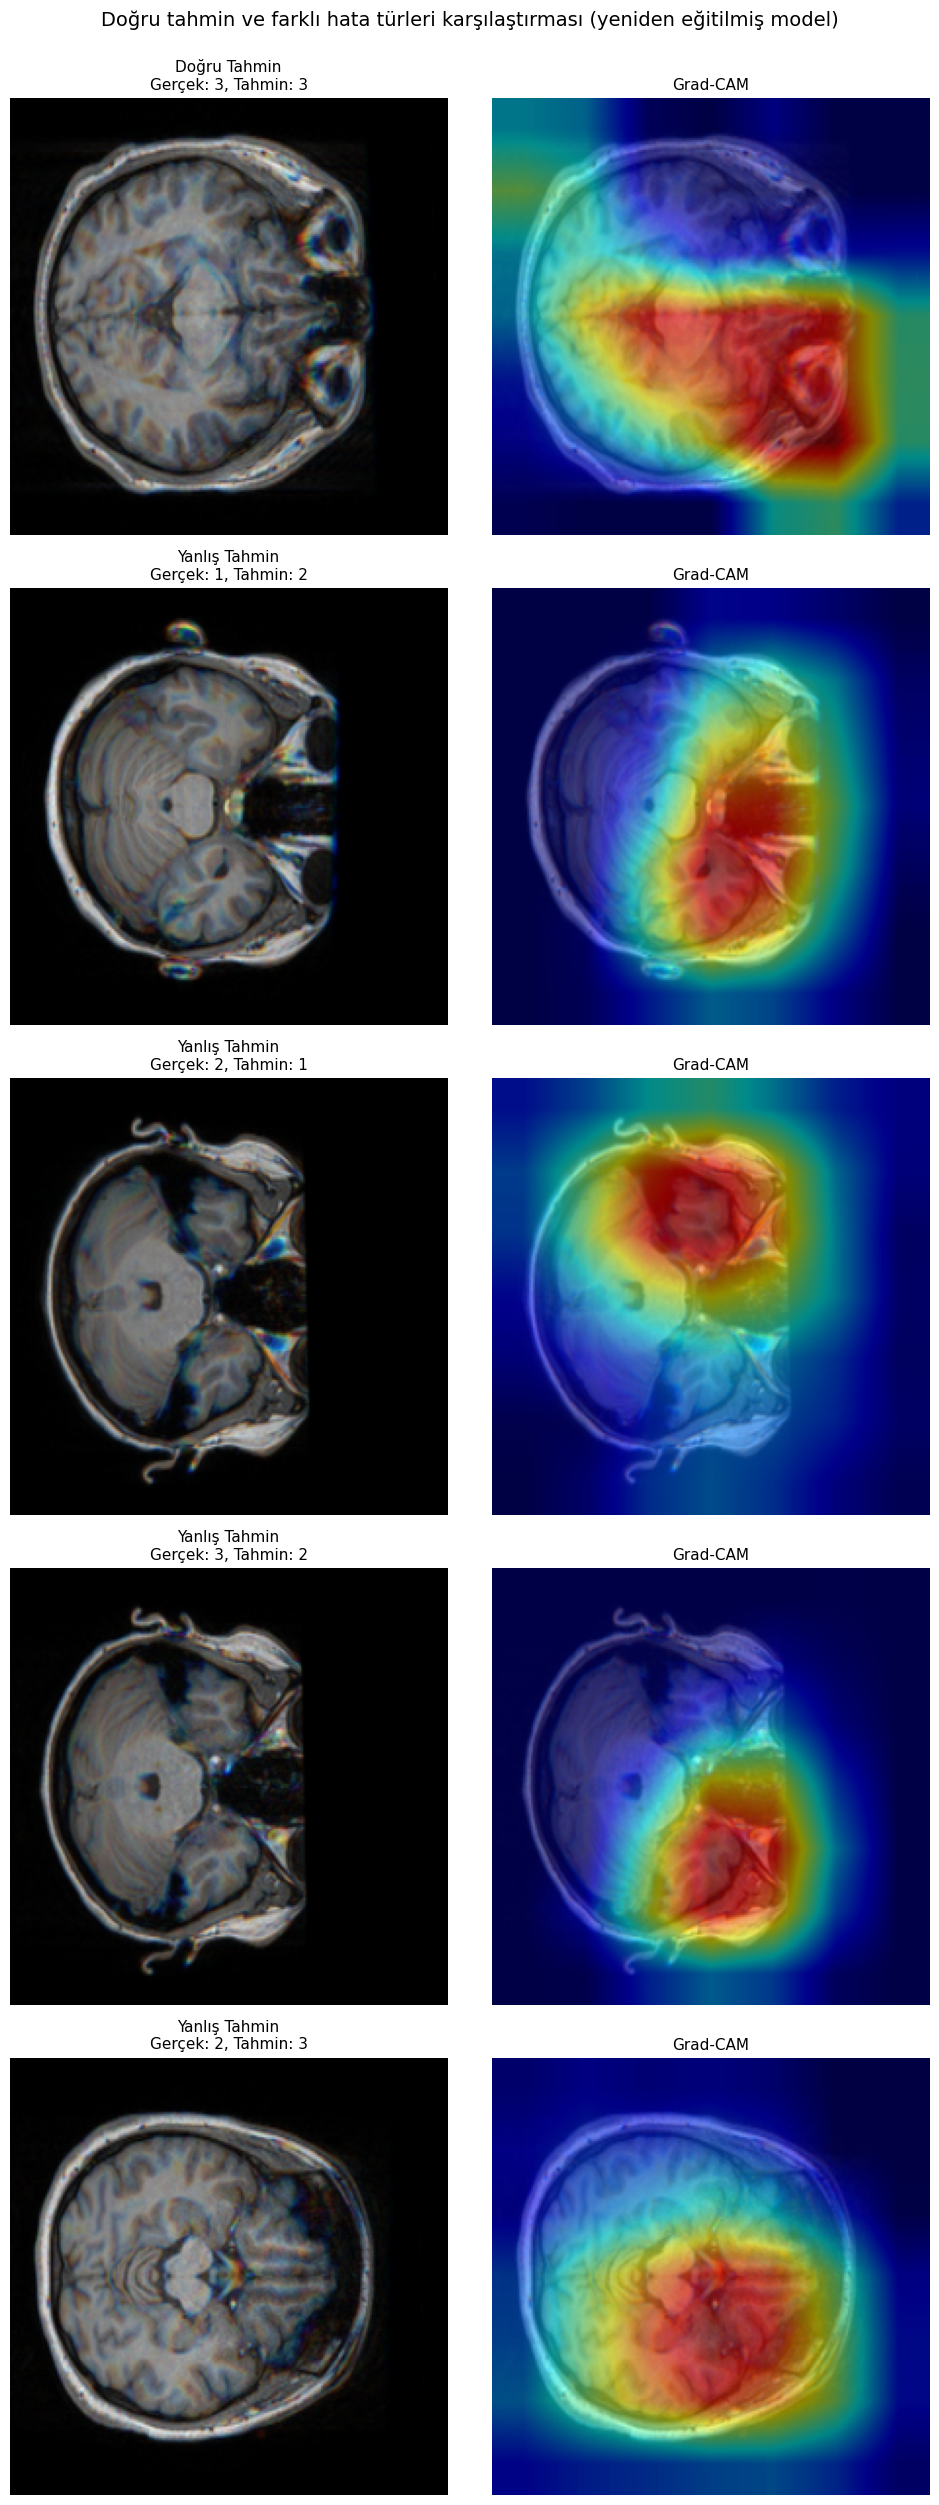

Kaydedildi.


In [3]:
wrong_idx_all = np.where(test_labels_ms != test_preds_ms)[0]
seen_combos = set()
diverse_wrong = []
for idx in wrong_idx_all:
    combo = (test_labels_ms[idx], test_preds_ms[idx])
    if combo not in seen_combos:
        seen_combos.add(combo)
        diverse_wrong.append(idx)

correct_idx = np.where(test_labels_ms == test_preds_ms)[0][0]
examples = [(correct_idx, "Doğru Tahmin")] + [(idx, "Yanlış Tahmin") for idx in diverse_wrong]

fig, axes = plt.subplots(len(examples), 2, figsize=(10, 5*len(examples)))

for row, (idx, label) in enumerate(examples):
    img_tensor, _ = test_dataset[idx]
    input_tensor = img_tensor.unsqueeze(0).to(device)
    targets = [ClassifierOutputTarget(test_preds_ms[idx])]
    grayscale_cam = cam(input_tensor=input_tensor, targets=targets)[0]

    img_display = img_tensor.permute(1, 2, 0).numpy()
    img_display = img_display * np.array([0.229, 0.224, 0.225]) + np.array([0.485, 0.456, 0.406])
    img_display = np.clip(img_display, 0, 1)
    visualization = show_cam_on_image(img_display, grayscale_cam, use_rgb=True)

    axes[row, 0].imshow(img_display)
    axes[row, 0].set_title(f"{label}\nGerçek: {test_labels_ms[idx]+1}, Tahmin: {test_preds_ms[idx]+1}", fontsize=11)
    axes[row, 0].axis('off')
    axes[row, 1].imshow(visualization)
    axes[row, 1].set_title("Grad-CAM", fontsize=11)
    axes[row, 1].axis('off')

plt.suptitle("Doğru tahmin ve farklı hata türleri karşılaştırması (yeniden eğitilmiş model)", fontsize=14, y=1.0)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/gradcam_all_error_types_v2.png', dpi=150, bbox_inches='tight')
plt.show()
print("Kaydedildi.")

In [4]:

model = models.resnet18(weights='IMAGENET1K_V1')
model.fc = nn.Linear(model.fc.in_features, 3)
model = model.to(device)
optimizer = optim.Adam(model.parameters(), lr=1e-4)

num_epochs = 3
history_best = []

for epoch in range(num_epochs):
    model.train()
    running_loss, correct, total = 0, 0, 0

    progress_bar = tqdm(train_loader_multi, desc=f'Epoch {epoch+1}/{num_epochs}')
    for images, labels in progress_bar:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
        progress_bar.set_postfix(loss=loss.item(), acc=correct/total)

    train_loss = running_loss / len(train_loader_multi)
    train_acc = correct / total
    val_loss, val_acc = evaluate_epoch(val_loader)

    print(f'Epoch {epoch+1}/{num_epochs} — Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | Val Loss: {val_loss:.4f} Acc: {val_acc:.4f}')
    history_best.append({'epoch': epoch+1, 'train_loss': train_loss, 'train_acc': train_acc, 'val_loss': val_loss, 'val_acc': val_acc})


torch.save(model.state_dict(), f'{OUTPUT_DIR}/resnet18_multislice_best_epoch3.pth')
print("En iyi (3. epoch) model ayrı olarak kaydedildi: resnet18_multislice_best_epoch3.pth")

Epoch 1/3:   0%|          | 0/95 [00:00<?, ?it/s]

Epoch 1/3 — Train Loss: 0.6983 Acc: 0.6914 | Val Loss: 0.4889 Acc: 0.8030


Epoch 2/3:   0%|          | 0/95 [00:00<?, ?it/s]

Epoch 2/3 — Train Loss: 0.5191 Acc: 0.7781 | Val Loss: 0.5387 Acc: 0.8030


Epoch 3/3:   0%|          | 0/95 [00:00<?, ?it/s]

Epoch 3/3 — Train Loss: 0.4003 Acc: 0.8477 | Val Loss: 0.8583 Acc: 0.6970
En iyi (3. epoch) model ayrı olarak kaydedildi: resnet18_multislice_best_epoch3.pth


In [11]:
# --- 1. Drive ---
from google.colab import drive
drive.mount('/content/drive')

import os
DRIVE_ROOT = '/content/drive/MyDrive/mrart_project'
DATA_DIR = f'{DRIVE_ROOT}/ds004173'
LOCAL_DATA_DIR = '/content/ds004173'
OUTPUT_DIR = f'{DRIVE_ROOT}/outputs'
os.makedirs(DRIVE_ROOT, exist_ok=True)
os.makedirs(OUTPUT_DIR, exist_ok=True)

# --- 2. Paketler ---
!pip install -q nibabel awscli grad-cam tqdm

# --- 3. Veriyi local diske kopyala ---
!mkdir -p "{LOCAL_DATA_DIR}"
!rsync -a --info=progress2 "{DATA_DIR}/" "{LOCAL_DATA_DIR}/"
print("Kopyalama tamamlandı.")

# --- 4. Veriyi yükle ---
import pandas as pd
import numpy as np
import nibabel as nib
import matplotlib.pyplot as plt
from pathlib import Path

data_path = Path(LOCAL_DATA_DIR)
participants = pd.read_csv(data_path / 'participants.tsv', sep='\t')
scores = pd.read_csv(data_path / 'derivatives' / 'scores.tsv', sep='\t')
mriqc = pd.read_csv(data_path / 'derivatives' / 'mriqc-0.16.1' / 'group_T1w.tsv', sep='\t')
merged = mriqc.merge(scores, on='bids_name', how='inner')

# --- 5. Subject-level split ---
from sklearn.model_selection import train_test_split

subjects = participants['participant_id'].unique()
train_subj, temp_subj = train_test_split(subjects, test_size=0.3, random_state=42)
val_subj, test_subj = train_test_split(temp_subj, test_size=0.5, random_state=42)

def assign_split(bids_name):
    subj = bids_name.split('_')[0]
    if subj in train_subj: return 'train'
    elif subj in val_subj: return 'val'
    else: return 'test'

merged['split'] = merged['bids_name'].apply(assign_split)
test_df = merged[merged['split'] == 'test']

# --- 6. Torch/model gereksinimleri ---
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from PIL import Image
from sklearn.metrics import balanced_accuracy_score, f1_score, classification_report, confusion_matrix, roc_auc_score

eval_transform = transforms.Compose([
    transforms.Resize((224, 224)), transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

class MRIQualityDataset(Dataset):
    def __init__(self, df, data_path, transform=None):
        self.df = df.reset_index(drop=True)
        self.data_path = data_path
        self.transform = transform
    def __len__(self):
        return len(self.df)
    def _get_2p5d_slice(self, bids_name):
        subject = bids_name.split('_')[0]
        fpath = self.data_path / subject / 'anat' / f'{bids_name}.nii.gz'
        vol = nib.load(fpath).get_fdata()
        z = vol.shape[2] // 2
        stack = np.stack([vol[:, :, z-1], vol[:, :, z], vol[:, :, z+1]], axis=-1)
        stack = stack - stack.min()
        return (stack / (stack.max() + 1e-8) * 255).astype(np.uint8)
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = Image.fromarray(self._get_2p5d_slice(row['bids_name']))
        if self.transform: img = self.transform(img)
        return img, int(row['score']) - 1

test_dataset = MRIQualityDataset(test_df, data_path, transform=eval_transform)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Using device:', device)

# --- 7. Epoch-3 modelini yükle ---
model = models.resnet18(weights=None)
model.fc = nn.Linear(model.fc.in_features, 3)
model.load_state_dict(torch.load(f'{OUTPUT_DIR}/resnet18_multislice_best_epoch3.pth'))
model = model.to(device)
model.eval()
print("Epoch-3 modeli yüklendi.")

# --- 8. Çoklu-kesit değerlendirme fonksiyonları ---
def evaluate_multislice(df, offsets=[-10, -5, 0, 5, 10]):
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for _, row in df.iterrows():
            slices = []
            for offset in offsets:
                subject = row['bids_name'].split('_')[0]
                fpath = data_path / subject / 'anat' / f"{row['bids_name']}.nii.gz"
                vol = nib.load(fpath).get_fdata()
                z = vol.shape[2] // 2 + offset
                stack = np.stack([vol[:, :, z-1], vol[:, :, z], vol[:, :, z+1]], axis=-1)
                stack = stack - stack.min()
                stack = (stack / (stack.max() + 1e-8) * 255).astype(np.uint8)
                img = eval_transform(Image.fromarray(stack))
                slices.append(img)
            batch = torch.stack(slices).to(device)
            outputs = model(batch)
            probs = F.softmax(outputs, dim=1)
            avg_probs = probs.mean(dim=0)
            pred = torch.argmax(avg_probs).item()
            all_preds.append(pred)
            all_labels.append(int(row['score']) - 1)
    return np.array(all_labels), np.array(all_preds)

def get_multislice_probs(df, offsets=[-10, -5, 0, 5, 10]):
    model.eval()
    all_probs, all_labels = [], []
    with torch.no_grad():
        for _, row in df.iterrows():
            slices = []
            for offset in offsets:
                subject = row['bids_name'].split('_')[0]
                fpath = data_path / subject / 'anat' / f"{row['bids_name']}.nii.gz"
                vol = nib.load(fpath).get_fdata()
                z = vol.shape[2] // 2 + offset
                stack = np.stack([vol[:, :, z-1], vol[:, :, z], vol[:, :, z+1]], axis=-1)
                stack = stack - stack.min()
                stack = (stack / (stack.max() + 1e-8) * 255).astype(np.uint8)
                img = eval_transform(Image.fromarray(stack))
                slices.append(img)
            batch = torch.stack(slices).to(device)
            outputs = model(batch)
            probs = F.softmax(outputs, dim=1)
            avg_probs = probs.mean(dim=0).cpu().numpy()
            all_probs.append(avg_probs)
            all_labels.append(int(row['score']) - 1)
    return np.array(all_labels), np.array(all_probs)

# --- 9. Test seti değerlendirmesi ---
test_labels_ep3, test_preds_ep3 = evaluate_multislice(test_df)

print("EPOCH 3 MODELİ — TEST SETİ")
print(f'Balanced accuracy: {balanced_accuracy_score(test_labels_ep3, test_preds_ep3):.3f}')
print(f'Macro F1: {f1_score(test_labels_ep3, test_preds_ep3, average="macro"):.3f}')
print(classification_report(test_labels_ep3, test_preds_ep3))
print(confusion_matrix(test_labels_ep3, test_preds_ep3))

ep3_test_labels, ep3_test_probs = get_multislice_probs(test_df)
auc_ep3 = roc_auc_score(ep3_test_labels, ep3_test_probs, multi_class='ovr')
print(f"AUROC: {auc_ep3:.3f}")
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget

target_layer = [model.layer4[-1]]
cam = GradCAM(model=model, target_layers=target_layer)

wrong_idx_all = np.where(test_labels_ep3 != test_preds_ep3)[0]
seen_combos = set()
diverse_wrong = []
for idx in wrong_idx_all:
    combo = (test_labels_ep3[idx], test_preds_ep3[idx])
    if combo not in seen_combos:
        seen_combos.add(combo)
        diverse_wrong.append(idx)

correct_idx = np.where(test_labels_ep3 == test_preds_ep3)[0][0]
examples = [(correct_idx, "Doğru Tahmin")] + [(idx, "Yanlış Tahmin") for idx in diverse_wrong]

fig, axes = plt.subplots(len(examples), 2, figsize=(10, 5*len(examples)))

for row, (idx, label) in enumerate(examples):
    img_tensor, _ = test_dataset[idx]
    input_tensor = img_tensor.unsqueeze(0).to(device)
    targets = [ClassifierOutputTarget(test_preds_ep3[idx])]
    grayscale_cam = cam(input_tensor=input_tensor, targets=targets)[0]

    img_display = img_tensor.permute(1, 2, 0).numpy()
    img_display = img_display * np.array([0.229, 0.224, 0.225]) + np.array([0.485, 0.456, 0.406])
    img_display = np.clip(img_display, 0, 1)
    visualization = show_cam_on_image(img_display, grayscale_cam, use_rgb=True)

    axes[row, 0].imshow(img_display)
    axes[row, 0].set_title(f"{label}\nGerçek: {test_labels_ep3[idx]+1}, Tahmin: {test_preds_ep3[idx]+1}", fontsize=11)
    axes[row, 0].axis('off')
    axes[row, 1].imshow(visualization)
    axes[row, 1].set_title("Grad-CAM", fontsize=11)
    axes[row, 1].axis('off')

plt.suptitle("Epoch-3 (erken durdurma) modeli — Grad-CAM", fontsize=14, y=1.0)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/gradcam_epoch3_model.png', dpi=150, bbox_inches='tight')
plt.show()
print("Kaydedildi: gradcam_epoch3_model.png")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
rsync: [sender] change_dir "/content/drive/MyDrive/mrart_project/ds004173" failed: No such file or directory (2)
              0 100%    0.00kB/s    0:00:00 (xfr#0, to-chk=0/0)
rsync error: some files/attrs were not transferred (see previous errors) (code 23) at main.c(1356) [sender=3.2.7]
Kopyalama tamamlandı.


FileNotFoundError: [Errno 2] No such file or directory: '/content/ds004173/participants.tsv'

In [12]:
import os

DRIVE_ROOT = '/content/drive/MyDrive/mrart_project'
DATA_DIR = f'{DRIVE_ROOT}/ds004173'

print("mrart_project içeriği:", os.listdir(DRIVE_ROOT))
print("ds004173 var mı:", os.path.exists(DATA_DIR))
if os.path.exists(DATA_DIR):
    print("İçinde kaç dosya var:", len(os.listdir(DATA_DIR)))

mrart_project içeriği: ['outputs']
ds004173 var mı: False
